<div align="center">

<!-- Judul Laporan -->
<h1><strong>LAPORAN UJIAN TENGAH SEMESTER</strong></h1>
<h2><strong>METODA KOMPUTASI II</strong></h2>
<h4><strong>Dosen Pengampu:</strong></h4>
<ul style="list-style-type: none; padding-left: 0;">
  <li>Dr. Muhammad Taufiq Rafie, S.Si., M.T.</li>
  <li>Dr. Muhammad Alimuddin, Eng.</li>
  <li>Muhammad Farid Wajedy, S.Si., M.Si.</li>
</ul>

<!-- Logo Universitas -->
<img src="https://www.unhas.ac.id/wp-content/uploads/2022/09/Logo-Resmi-Unhas-1.png" 
     alt="Logo Universitas Hasanuddin" 
     style="width:250px; margin:20px 0;">

<!-- Penulis -->
<h3>Disusun Oleh:</h3>
<p><strong>KELOMPOK 2B</strong></p>
<ul style="list-style:none; padding-left:0; line-height:1.8; width:400px;">
  <li style="display:flex; justify-content:space-between;"><span>Arya Putra Pratama</span><span>(H061241077)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Nurul Hijrah</span><span>(H061241083)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Piara</span><span>(H061241046)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Yuni</span><span>(H061241072)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Prita Laura Priskilla Pontengi</span><span>(H061241047)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Ilham Saputra</span><span>(H061241076)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Putri Meylani</span><span>(H061241088)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Alwansyah</span><span>(H061241090)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>M. Padil Mangulele</span><span>(H061241071)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Gracia Aurelya Krisma</span><span>(H061241066)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Muhammad Zulfan Azima</span><span>(H061241056)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Risil Thia Mangape'</span><span>(H061241075)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Dwi Rezky Maharani</span><span>(H061241078)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Muhammad Lucky Sandriand</span><span>(H061241044)</span></li>
  <li style="display:flex; justify-content:space-between;"><span>Nurafika Az Dzkira</span><span>(H061241076)</span></li>
</ul>

<!-- Departemen dan Fakultas -->
<p><strong>DEPARTEMEN GEOFISIKA</strong></p>
<p><strong>FAKULTAS MATEMATIKA DAN ILMU PENGETAHUAN ALAM</strong></p>
<p><strong>UNIVERSITAS HASANUDDIN</strong></p>
<p><strong>MAKASSAR</strong></p>

<!-- Tahun -->
<p><strong>2026</strong></p>

</div>

# **Metode Finite Element (FEM)**

Metode finite element (FEM) adalah sebuah cara untuk mengubah persamaan diferensial parsial (PDE) yang sifatnya kontinu menjadi persamaan sistem linier atau diskrit non-linier. Metode ini sangat populer di bidang Teknik dan Mekanika Solid, meskipun sebenarnya bisa digunakan untuk bidang apa saja. Metode seperti membagi suatu objek atau daerah menjadi banyak elemen kecil yang jumlahnya terbatas, lalu dihitung satu per satu untuk mendapatkan solusi.

Ide utama dalam FEM adalah kita memikirkan fungsi kontinu $f(x)$ sebagai kombinasi linier dari sejumlah fungsi dasar yang terbatas:
$$
    f_h(x) = \sum_{i=0}^N w_i \phi_i(x) 
$$


Di mana $\phi_i(x)$ adalah fungsi dasar dan $w_i$ adalah sekumpulan bobot. Kita telah melihat dekomposisi yang serupa pada Spectral Methods. Namun, alih-alih menggunakan fungsi basis global seperti $\sin(kx)$ atau polinomial Chebyshev, pada metode ini kita (sebagian besar) akan menggunakan polinomial berbentuk potongan (piecewise polynomials).

### **Fungsi Linear Sepenggal pada Satu Dimensi (P1)**

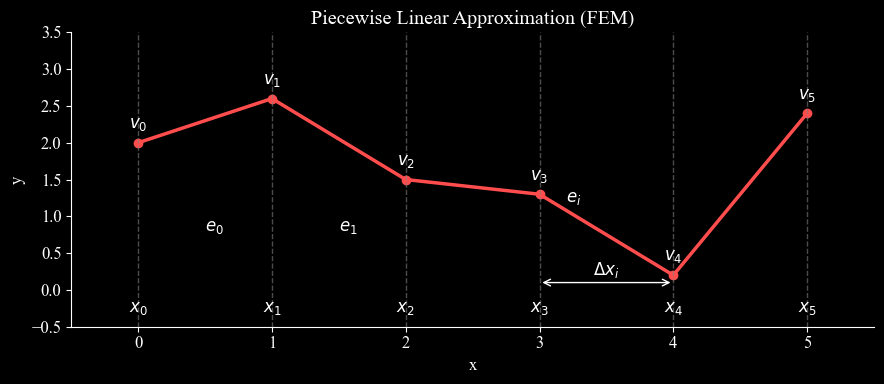

In [ ]:
import numpy as np                              # komputasi numerik
import matplotlib.pyplot as plt                 # plotting

plt.style.use('dark_background')                # tema gelap
plt.rcParams['font.family'] = 'Times New Roman' # font TNR
plt.rcParams['font.size'] = 12                  # ukuran font

# Node (x_i) dan nilai v_i
x = np.array([0, 1, 2, 3, 4, 5])               # posisi node
v = np.array([2.0, 2.6, 1.5, 1.3, 0.2, 2.4])   # nilai fungsi di node

fig, ax = plt.subplots(figsize=(9,4))          # figure

ax.plot(x, v,
        color='#ff4d4d',                       # merah
        linewidth=2.5,
        marker='o',
        label="v(x)")

# Garis vertikal (elemen)
for xi in x:
    ax.axvline(x=xi,
               color='gray',
               linestyle='--',
               linewidth=1,
               alpha=0.6)

# Label titik v_i
for i in range(len(x)):
    ax.text(x[i], v[i] + 0.2,
            f"$v_{i}$",                        # label vi
            ha='center')

# Label x_i
for i in range(len(x)):
    ax.text(x[i], -0.3,
            f"$x_{i}$",                        # label xi
            ha='center')

# Highlight Δx_i
ax.annotate("",
            xy=(x[3], 0.1),
            xytext=(x[4], 0.1),
            arrowprops=dict(arrowstyle='<->', color='white'))

ax.text((x[3]+x[4])/2, 0.2,
        r"$\Delta x_i$",
        ha='center')

# Label elemen e_i
ax.text(0.5, 0.8, r"$e_0$")
ax.text(1.5, 0.8, r"$e_1$")
ax.text(3.2, 1.2, r"$e_i$")

# Styling
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 3.5)

ax.set_xlabel("x")                             # sumbu x
ax.set_ylabel("y")                             # sumbu y
ax.set_title("Piecewise Linear Approximation (FEM)")  # judul

ax.grid(False)

# hilangkan frame atas kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Sebagai contoh, perhatikan fungsi linear sepenggal (*piecewise linear*) “connect the dots” yang ditunjukkan pada gambar di atas. Pada kasus ini, suatu interval $I = [x_0, x_5]$ diuraikan menjadi 5 sub-interval atau *elemen* $e_i = [x_i, x_{i+1}]$ dengan $i = 0, 1, 2, 3, 4$.

Pada setiap interval tersebut, fungsi $v_h$ merupakan fungsi linear terhadap $x$, dan setiap segmen bersifat kontinu pada batas antar elemen. Gambar ini merupakan modifikasi dari Gambar 1.1 oleh Claes Johnson Larson dan Fredrik Bengzon.

Walaupun $v_h(x)$ adalah fungsi kontinu yang dapat dievaluasi untuk setiap nilai $x$, penting untuk dipahami bahwa sebenarnya hanya terdapat 6 derajat kebebasan (*degrees of freedom*), yang bersesuaian dengan nilai pada titik simpul (*node*), yaitu:

$$
\vec{v} = [v_0, v_1, v_2, v_3, v_4, v_5]
$$

Dengan hanya mengubah keenam nilai tersebut, kita dapat menghasilkan jumlah tak hingga fungsi linear sepenggal pada triangulasi ini. Ruang fungsi berdimensi hingga ini disebut $\mathcal{V}_h$, yang sepenuhnya dideskripsikan oleh sebuah mesh elemen dan sebuah fungsi interpolasi pada setiap elemen.

### **Fungsi Basis Global**

Diberikan suatu ruang fungsi diskrit $\mathcal{V}_h$, setiap fungsi $v_h \in \mathcal{V}_h$ dapat dinyatakan sebagai kombinasi dari sekumpulan fungsi basis yang merentang ruang tersebut.

Dalam kasus ruang fungsi linear sepenggal satu dimensi (1-D), fungsi basis global diberikan oleh *hat functions* sebagai berikut:

$$
\phi_i(x) =
\begin{cases}
\dfrac{x - x_{i-1}}{\Delta x_{i-1}}, & x \in e_{i-1} \\
\dfrac{x_i - x}{\Delta x_i}, & x \in e_i \\
0, & \text{lainnya}
\end{cases}
$$

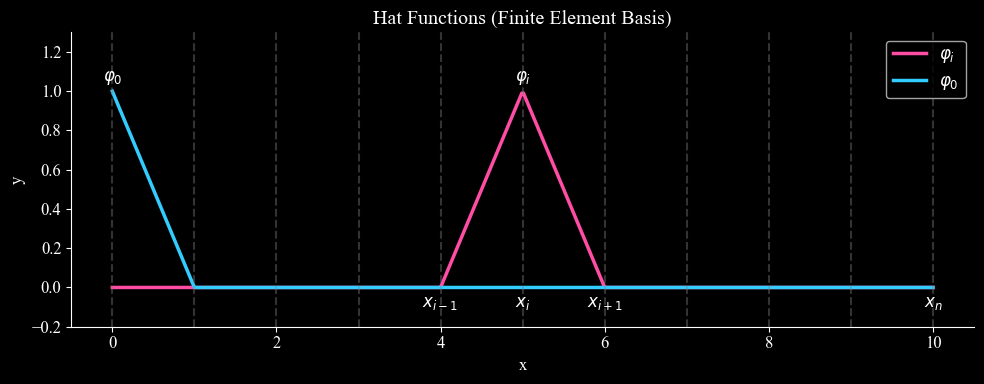

In [ ]:
import numpy as np                              # komputasi numerik
import matplotlib.pyplot as plt                 # plotting

plt.style.use('dark_background')                # tema gelap
plt.rcParams['font.family'] = 'Times New Roman' # font TNR
plt.rcParams['font.size'] = 12                  # ukuran font

# Grid (node)
x = np.linspace(0, 10, 11)                      # node x0 ... xn

# pilih node tengah untuk φ_i
i = 5                                           # indeks tengah

# Definisi hat function φ_i
def hat_function(x_vals, x_nodes, i):           # fungsi basis FEM
    phi = np.zeros_like(x_vals)                 # inisialisasi nol

    for k, xv in enumerate(x_vals):             # loop setiap titik
        if x_nodes[i-1] <= xv <= x_nodes[i]:    # sisi kiri segitiga
            phi[k] = (xv - x_nodes[i-1]) / (x_nodes[i] - x_nodes[i-1])
        elif x_nodes[i] < xv <= x_nodes[i+1]:   # sisi kanan segitiga
            phi[k] = (x_nodes[i+1] - xv) / (x_nodes[i+1] - x_nodes[i])
    
    return phi

# Half-hat φ0 (boundary)
def half_hat(x_vals, x_nodes):                  # φ0
    phi = np.zeros_like(x_vals)

    for k, xv in enumerate(x_vals):
        if x_nodes[0] <= xv <= x_nodes[1]:
            phi[k] = (x_nodes[1] - xv) / (x_nodes[1] - x_nodes[0])

    return phi

# Domain kontinu
xx = np.linspace(0, 10, 500)                    # domain halus

phi_i = hat_function(xx, x, i)                  # φ_i
phi_0 = half_hat(xx, x)                         # φ_0

# Plot
fig, ax = plt.subplots(figsize=(10,4))          # figure

# φ_i (tengah)
ax.plot(xx, phi_i,
        color='#ff4da6',                        # pink
        linewidth=2.5,
        label=r"$\varphi_i$")

# φ_0 (half hat kiri)
ax.plot(xx, phi_0,
        color='#33ccff',                        # cyan
        linewidth=2.5,
        label=r"$\varphi_0$")

# Garis vertikal node
for xi in x:
    ax.axvline(x=xi,
               color='gray',
               linestyle='--',
               alpha=0.4)

# Label titik penting
ax.text(x[i], 1.05, r"$\varphi_i$", ha='center')      # label φ_i
ax.text(x[0], 1.05, r"$\varphi_0$", ha='center')      # label φ_0

ax.text(x[i-1], -0.1, r"$x_{i-1}$", ha='center')      # label kiri
ax.text(x[i],   -0.1, r"$x_i$", ha='center')          # label tengah
ax.text(x[i+1], -0.1, r"$x_{i+1}$", ha='center')      # label kanan
ax.text(x[-1],  -0.1, r"$x_n$", ha='center')          # label ujung

# Styling
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.2, 1.3)

ax.set_xlabel("x")                             # sumbu x
ax.set_ylabel("y")                             # sumbu y
ax.set_title("Hat Functions (Finite Element Basis)")  # judul

ax.legend()                                    # legenda

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Fungsi ini memiliki sifat penting yaitu $\phi_i(x_j) = \delta_{ij}$. Sebuah contoh fungsi hat ditunjukkan pada Gambar dari Larson dan Bengzon.


Meskipun hal ini tidak sepenuhnya jelas, kita dapat membangun semua fungsi linear sepenggal dalam $\mathcal{V}_h$ sebagai kombinasi linear dari fungsi-fungsi hat tersebut, yaitu
$$
f_h(x) = \sum_{i=0}^5 w_i\phi_i(x) 
$$t

### **Fungsi Basis Lokal**

Untuk memperjelas hal ini, perlu dilihat bagaimana fungsi-fungsi basis tersebut melakukan interpolasi terhadap $v$ pada satu elemen.


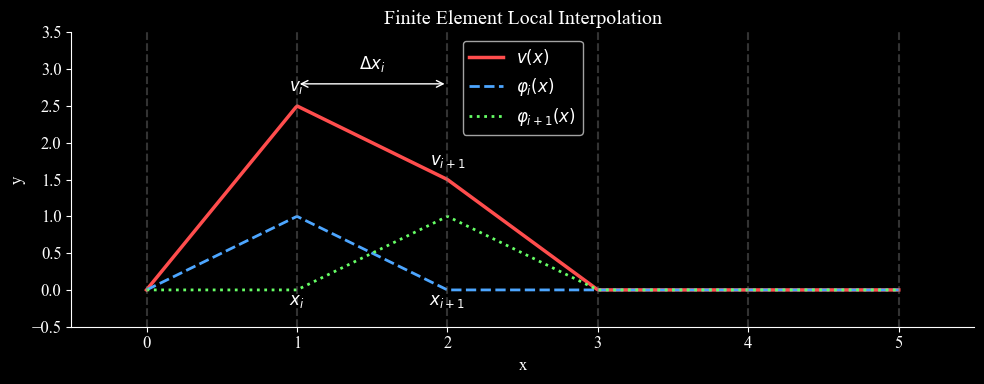

In [ ]:
import numpy as np                              # komputasi numerik
import matplotlib.pyplot as plt                 # plotting

plt.style.use('dark_background')                # tema gelap
plt.rcParams['font.family'] = 'Times New Roman' # font TNR
plt.rcParams['font.size'] = 12                  # ukuran font

# Node setup
x_nodes = np.array([0, 1, 2, 3, 4, 5])          # node global
v_nodes = np.array([2.0, 2.5, 1.5, 1.3, 0.3, 2.2])  # nilai v(x)

i = 1                                           # elemen ke-i (xi ke xi+1)

x = np.linspace(0, 5, 500)                      # domain kontinu

def phi_i(x):
    return np.where(
        (x >= x_nodes[i-1]) & (x <= x_nodes[i]),
        (x - x_nodes[i-1]) / (x_nodes[i] - x_nodes[i-1]),
        np.where(
            (x > x_nodes[i]) & (x <= x_nodes[i+1]),
            (x_nodes[i+1] - x) / (x_nodes[i+1] - x_nodes[i]),
            0))

# Fungsi basis φ_{i+1}
def phi_ip1(x):
    return np.where(
        (x >= x_nodes[i]) & (x <= x_nodes[i+1]),
        (x - x_nodes[i]) / (x_nodes[i+1] - x_nodes[i]),
        np.where(
            (x > x_nodes[i+1]) & (x <= x_nodes[i+2]),
            (x_nodes[i+2] - x) / (x_nodes[i+2] - x_nodes[i+1]),
            0))

# Interpolasi lokal v(x)
v_local = v_nodes[i]*phi_i(x) + v_nodes[i+1]*phi_ip1(x)

fig, ax = plt.subplots(figsize=(10,4))          # figure

ax.plot(x, v_local,
        color='#ff4d4d',
        linewidth=2.5,
        label=r"$v(x)$")

ax.plot(x, phi_i(x),
        color='#4da6ff',
        linewidth=2,
        linestyle='--',
        label=r"$\varphi_i(x)$")

ax.plot(x, phi_ip1(x),
        color='#66ff66',
        linewidth=2,
        linestyle=':',
        label=r"$\varphi_{i+1}(x)$")

# Garis node (vertikal)
for xn in x_nodes:
    ax.axvline(x=xn,
               color='gray',
               linestyle='--',
               alpha=0.4)

# Label node
ax.text(x_nodes[i], -0.2, r"$x_i$", ha='center')
ax.text(x_nodes[i+1], -0.2, r"$x_{i+1}$", ha='center')

# Label nilai v_i
ax.text(x_nodes[i], v_nodes[i]+0.2, r"$v_i$", ha='center')
ax.text(x_nodes[i+1], v_nodes[i+1]+0.2, r"$v_{i+1}$", ha='center')

# Δx_i
ax.annotate("",
            xy=(x_nodes[i], 2.8),
            xytext=(x_nodes[i+1], 2.8),
            arrowprops=dict(arrowstyle='<->', color='white'))

ax.text((x_nodes[i]+x_nodes[i+1])/2, 3.0,
        r"$\Delta x_i$", ha='center')

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 3.5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Finite Element Local Interpolation")

ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Perhatikan hanya bagian dari $v(x)$ yang berada pada elemen $e_i$. Pada elemen ini, satu-satunya fungsi basis global yang memiliki dukungan (*support*) adalah $\phi_i(x)$ dan $\phi_{i+1}(x)$.

Dengan demikian, pada elemen tersebut berlaku:

$$
v(x) = v_i \phi_i(x) + v_{i+1} \phi_{i+1}(x), \quad x \in [x_i, x_{i+1}]
$$

Hal ini konsisten pada titik-titik simpul (*node*), karena fungsi basis memenuhi sifat:

$$
\phi_i(x_j) = \delta_{ij}
$$

Di antara titik-titik simpul (*node*), fungsi basis $\phi_i$ dan $\phi_{i+1}$ berperan untuk membentuk interpolasi linear pada setiap elemen. Artinya, nilai fungsi di dalam elemen tidak dihitung secara langsung dari bentuk global, tetapi dibangun dari kontribusi lokal yang sederhana.

Untuk memahami hal ini dengan lebih jelas, kita fokus pada satu elemen $e_i = [x_i, x_{i+1}]$. Pada elemen ini, kita dapat mendefinisikan *fungsi basis lokal* yang merupakan bagian dari fungsi basis global, yaitu:

$$
N_0(x) = \frac{x_{i+1} - x}{x_{i+1} - x_i}
$$

$$
N_1(x) = \frac{x - x_i}{x_{i+1} - x_i}
$$

Kedua fungsi ini adalah polinomial Lagrange orde 1 (linear) yang digunakan untuk melakukan interpolasi pada interval $[x_i, x_{i+1}]$. Secara intuitif:

- $N_0(x)$ bernilai 1 di $x_i$ dan 0 di $x_{i+1}$
- $N_1(x)$ bernilai 0 di $x_i$ dan 1 di $x_{i+1}$

Dengan kata lain, masing-masing fungsi basis lokal "mengambil peran" pada satu titik simpul.

Untuk melihat bentuk interpolasinya, misalkan kita ambil suatu titik di dalam elemen:
$$
x^* = x_i + s \, \Delta x_i
$$
dengan $\Delta x_i = x_{i+1} - x_i$ dan $s \in [0,1]$ adalah koordinat lokal (posisi relatif di dalam elemen).

Jika kita substitusikan ke dalam fungsi basis lokal, diperoleh:
$$
N_0(x^*) = 1 - s
$$

$$
N_1(x^*) = s
$$

Sehingga, fungsi $v(x)$ di dalam elemen dapat dituliskan sebagai:
$$
v(x) = v_i N_0(x) + v_{i+1} N_1(x)
$$

atau dalam bentuk yang lebih intuitif:
$$
v(x) = v_i (1 - s) + v_{i+1} s
$$

Bentuk ini menunjukkan bahwa nilai $v(x)$ merupakan interpolasi linear antara nilai di dua titik simpul, yaitu $v_i$ dan $v_{i+1}$.

Dengan demikian, fungsi global $v(x)$ pada seluruh domain $\Omega = [x_0, x_5]$ sebenarnya tersusun dari gabungan potongan-potongan fungsi linear lokal pada setiap elemen.

Dalam analisis metode elemen hingga (FEM), kita sering berpindah antara dua sudut pandang:
- Pandangan global, menggunakan fungsi basis $\phi_i(x)$
- Pandangan lokal (elemen), menggunakan fungsi basis $N_0(x)$ dan $N_1(x)$

Perpindahan ini dilakukan karena beberapa perhitungan (seperti integrasi dan pembentukan matriks) jauh lebih mudah dilakukan dalam koordinat lokal pada setiap elemen.

### **Ruang Fungsi Polinomial Orde Lebih Tinggi**

Ruang fungsi linear sepenggal sering disebut sebagai $P_1$, namun terdapat pilihan lain. Sebagai contoh, ruang fungsi kuadratik sepenggal ($P_2$) memiliki sekumpulan fungsi basis lokal yang merupakan polinomial Lagrange orde 2 dan memerlukan tiga derajat kebebasan pada setiap node.
Fungsi basis global kemudian dibangun dari fungsi basis lokal tersebut.

Visualisasi berikut menunjukkan sebagian fungsi basis untuk $P_2$, yang berbeda untuk derajat kebebasan pada pusat dan pada tepi elemen 


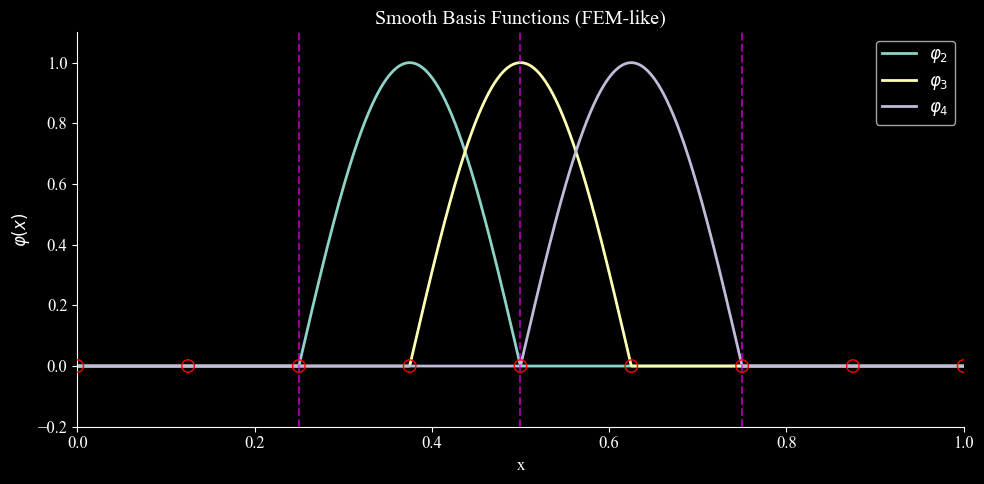

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Styling
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Grid domain
x_nodes = np.linspace(0, 1, 9)   # node (0 sampai 1)
xx = np.linspace(0, 1, 1000)     # domain halus

# Basis function (smooth lokal)
def phi(x, a, b):
    """
    Basis function lokal di interval [a,b]
    bentuk sinus (0 di ujung, 1 di tengah)
    """
    val = np.zeros_like(x)
    mask = (x >= a) & (x <= b)
    val[mask] = np.sin(np.pi * (x[mask] - a) / (b - a))
    return val

phi2 = phi(xx, x_nodes[2], x_nodes[4])   # biru
phi3 = phi(xx, x_nodes[3], x_nodes[5])   # merah
phi4 = phi(xx, x_nodes[4], x_nodes[6])   # hijau

fig, ax = plt.subplots(figsize=(10,5))

# kurva
ax.plot(xx, phi2, label=r'$\varphi_2$', linewidth=2)
ax.plot(xx, phi3, label=r'$\varphi_3$', linewidth=2)
ax.plot(xx, phi4, label=r'$\varphi_4$', linewidth=2)

# titik node (lingkaran merah)
ax.scatter(x_nodes, np.zeros_like(x_nodes),
           facecolors='none', edgecolors='red', s=80, zorder=3)

# garis vertikal putus-putus (node penting)
important_nodes = [x_nodes[2], x_nodes[4], x_nodes[6]]
for xn in important_nodes:
    ax.axvline(x=xn, linestyle='--', color='magenta', alpha=0.6)

ax.set_xlim(0, 1)
ax.set_ylim(-0.2, 1.1)

ax.set_xlabel("x")
ax.set_ylabel(r"$\varphi(x)$")
ax.set_title("Smooth Basis Functions (FEM-like)")

ax.legend()

# hilangkan frame atas kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### **Interpolasi suatu fungsi $f(x)$ ke dalam $\mathcal{V}_h$**

Diberikan suatu himpunan fungsi basis $\phi_i(x)$ untuk ruang fungsi $\mathcal{V}_h$, tidak semua fungsi dapat direpresentasikan secara tepat di dalam ruang ini. 

Sebagai contoh, jika diberikan suatu fungsi halus $f(x)$, maka diperlukan suatu pendekatan $f_h(x) \in \mathcal{V}_h$ yang mendekati $f(x)$.

Salah satu pendekatan yang paling sederhana adalah *interpolasi* atau *proyeksi* dari $f$ ke dalam $\mathcal{V}_h$, yang dinyatakan sebagai $\pi f$. Fungsi ini didefinisikan sebagai $\pi f \in \mathcal{V}_h$ dengan bentuk:

$$
\pi f(x) = \sum_{i=0}^{N} f(x_i)\,\phi_i(x)
$$

Dengan konstruksi ini, nilai fungsi pendekatan sama dengan nilai fungsi asli pada titik-titik simpul, yaitu:
$$
\pi f(x_i) = f(x_i)
$$

yaitu kedua fungsi tersebut memiliki kesalahan nol pada derajat kebebasan (degrees of freedom).

Visualisasi berikut menunjukkan interpolan linear dari suatu fungsi $f$ ke dalam satu elemen pada interval
$[x_0,x_1]$.

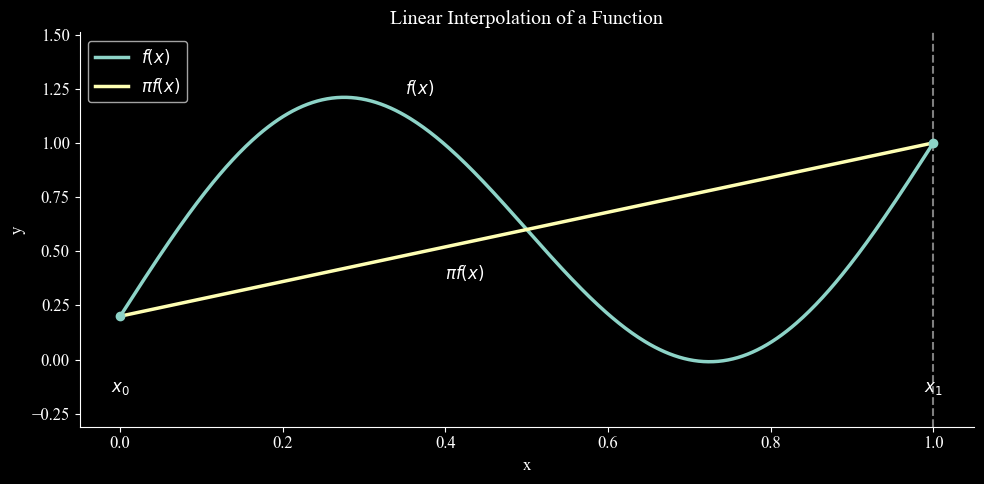

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

x0, x1 = 0, 1
xx = np.linspace(x0, x1, 500)

# Fungsi asli f(x)
def f(x):
    return 0.8*np.sin(2*np.pi*x) + 0.8*x + 0.2

# nilai di ujung interval
f0 = f(x0)
f1 = f(x1)

# Interpolasi linear πf(x)
def linear_interp(x):
    return f0 + ( (f1 - f0) / (x1 - x0) ) * (x - x0)

pi_f = linear_interp(xx)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

# fungsi asli
ax.plot(xx, f(xx),
        linewidth=2.5,
        label=r"$f(x)$")

# interpolasi linear
ax.plot(xx, pi_f,
        linewidth=2.5,
        linestyle='-',
        label=r"$\pi f(x)$")

# garis vertikal x1
ax.axvline(x=x1, linestyle='--', alpha=0.5)

# titik ujung
ax.scatter([x0, x1], [f0, f1], zorder=3)

ax.text(x0, -0.15, r"$x_0$", ha='center')
ax.text(x1, -0.15, r"$x_1$", ha='center')

ax.text(0.35, f(0.35)+0.1, r"$f(x)$")
ax.text(0.4, linear_interp(0.4)-0.15, r"$\pi f(x)$")

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(min(f(xx))-0.3, max(f(xx))+0.3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Linear Interpolation of a Function")

ax.legend()

# hilangkan frame atas kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Visulisasi berikut juga menunjukkan interpolan linear dari suatu fungsi $f$ ke dalam ruang fungsi linear sepenggal
$\mathcal{V}$.     

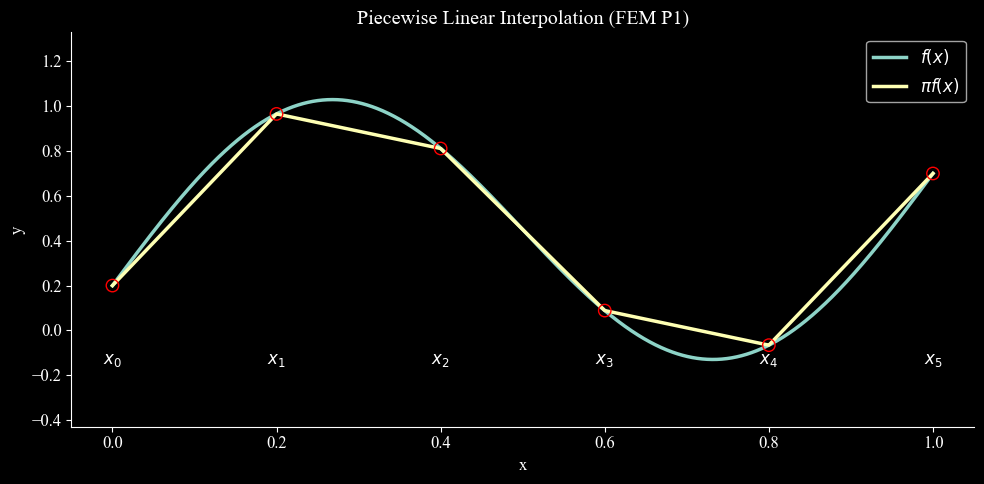

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

x_nodes = np.linspace(0, 1, 6)      # x0 ... x5
xx = np.linspace(0, 1, 1000)        # domain halus

def f(x):
    return 0.7*np.sin(2*np.pi*x) + 0.5*x + 0.2

# nilai di node
f_nodes = f(x_nodes)

def piecewise_linear(x, x_nodes, f_nodes):
    y = np.zeros_like(x)

    for i in range(len(x_nodes)-1):
        # ambil interval
        xL = x_nodes[i]
        xR = x_nodes[i+1]
        fL = f_nodes[i]
        fR = f_nodes[i+1]

        # mask interval
        mask = (x >= xL) & (x <= xR)

        # interpolasi linear lokal
        y[mask] = fL + ( (fR - fL)/(xR - xL) ) * (x[mask] - xL)

    return y

pi_f = piecewise_linear(xx, x_nodes, f_nodes)

fig, ax = plt.subplots(figsize=(10,5))

# fungsi asli
ax.plot(xx, f(xx),
        linewidth=2.5,
        label=r"$f(x)$")

# interpolasi piecewise
ax.plot(xx, pi_f,
        linewidth=2.5,
        label=r"$\pi f(x)$")

# node (lingkaran)
ax.scatter(x_nodes, f_nodes,
           facecolors='none',
           edgecolors='red',
           s=80,
           zorder=3)

for i, xn in enumerate(x_nodes):
    ax.text(xn, -0.15, rf"$x_{i}$", ha='center')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(min(f(xx))-0.3, max(f(xx))+0.3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Piecewise Linear Interpolation (FEM P1)")

ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 

### **Kesalahan Interpolasi**

Secara umum, akan terdapat perbedaan (kesalahan) antara fungsi asli $f(x)$ dan interpolannya $\pi f(x)$. Untuk mengukur kesalahan ini, diperlukan suatu norma, dan terdapat beberapa pilihan norma yang dapat digunakan.

Salah satu norma yang sering digunakan dalam metode elemen hingga adalah norma $L^2$ dari suatu fungsi pada domain $\Omega$, yaitu:

$$
\|f\|_{L^2(\Omega)} = \left( \int_{\Omega} f^2 \, dx \right)^{1/2}
$$

Selain itu, norma yang sama juga dapat didefinisikan pada suatu sub-interval $I$ (biasanya sebuah elemen), yaitu:

$$
\|f\|_{L^2(I)} = \left( \int_{I} f^2 \, dx \right)^{1/2}
$$

Diberikan definisi-definisi tersebut serta sifat dari interpolasi polinomial, kita dapat memperoleh perkiraan kesalahan interpolasi sebagai berikut.

**Kesalahan interpolasi pada satu elemen linear $P_1$**

$$
\| f - \pi f \|_{L^2(I)} \leq C \, \Delta x^2 \, \| f'' \|_{L^2(I)}
$$

dengan $I = [x_i, x_{i+1}]$, $\Delta x = x_{i+1} - x_i$, $C$ adalah suatu konstanta, dan $\|f''\|_{L^2(I)}$ menyatakan ukuran kelengkungan (*curvature*) fungsi pada interval tersebut. Jika $\Delta x = 0$ atau fungsi bersifat linear pada interval tersebut, maka kesalahannya bernilai nol.

**Kesalahan interpolasi pada seluruh domain**

Untuk fungsi polinomial sepenggal, kesalahan interpolasi pada $\mathcal{V}_h$ merupakan penjumlahan dari kesalahan pada setiap elemen, yaitu:

$$
\| f - \pi f \|^2_{L^2} \leq C \sum_{i=0}^{N} \Delta x_i^4 \, \| f'' \|^2_{L^2(I_i)}
$$

### **Konvergensi**   
Berdasarkan perkiraan kesalahan tersebut, jelas bahwa
interpolan akan konvergen menuju fungsi kontinu dalam
norma $L^2$ ketika $\Delta x \rightarrow 0$. Hal ini masuk
akal karena kita mengharapkan interpolan menjadi
pendekatan yang semakin baik terhadap $f$ ketika mesh
menjadi semakin halus.

Untuk fungsi $P_1$, kesalahan berkurang sebanding
dengan $\Delta x^2$. Interpolan orde lebih tinggi dari
fungsi yang halus smooth seharusnya
konvergen lebih cepat jika polinomial sepenggal orde
lebih tinggi tersebut merupakan pendekatan yang baik
terhadap fungsi kontinu $f$.

### **Proyeksi $L^2$ suatu fungsi $f(x)$ ke dalam $\mathcal{V}_h$**

Meskipun interpolan $\pi f$ konvergen menuju $f$ dalam norma $L^2$ ketika $\Delta x \to 0$, untuk nilai $\Delta x$ yang tetap, fungsi tersebut bukanlah elemen dalam $\mathcal{V}_h$ yang memberikan kesalahan $L^2$ terkecil.

Untuk itu, diperlukan proyeksi ortogonal dalam norma $L^2$, yaitu $P_h f$, yang merupakan fungsi unik $v_h \in \mathcal{V}_h$ yang meminimalkan:

$$
\| f - v_h \|_{L^2}
$$

visualisasi berikut menunjukkan proyeksi ortogonal dari $f$ ke dalam $\mathcal{V}_h$ untuk fungsi $f(x) = x \sin(\pi x)$.

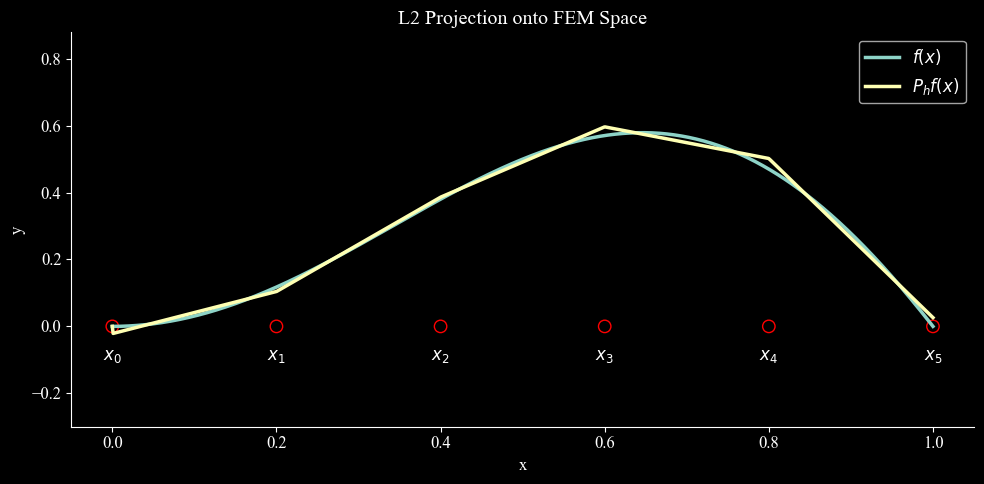

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

x_nodes = np.linspace(0, 1, 6)   # x0 ... x5
n = len(x_nodes)

xx = np.linspace(0, 1, 1000)

def f(x):
    return x * np.sin(np.pi * x)

def phi(i, x, nodes):
    val = np.zeros_like(x)

    if i > 0:
        left = (nodes[i-1] <= x) & (x <= nodes[i])
        val[left] = (x[left] - nodes[i-1]) / (nodes[i] - nodes[i-1])

    if i < len(nodes)-1:
        right = (nodes[i] < x) & (x <= nodes[i+1])
        val[right] = (nodes[i+1] - x[right]) / (nodes[i+1] - nodes[i])

    return val

M = np.zeros((n, n))
b = np.zeros(n)

# numerical integration (simple trapezoid)
x_int = np.linspace(0, 1, 1000)
dx = x_int[1] - x_int[0]

for i in range(n):
    phi_i = phi(i, x_int, x_nodes)

    for j in range(n):
        phi_j = phi(j, x_int, x_nodes)
        M[i, j] = np.sum(phi_i * phi_j) * dx

    b[i] = np.sum(f(x_int) * phi_i) * dx

# Solve sistem linear
c = np.linalg.solve(M, b)

# Bentuk solusi P_h f(x)
Ph = np.zeros_like(xx)
for i in range(n):
    Ph += c[i] * phi(i, xx, x_nodes)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

# fungsi asli
ax.plot(xx, f(xx), linewidth=2.5, label=r"$f(x)$")

# proyeksi FEM
ax.plot(xx, Ph, linewidth=2.5, label=r"$P_h f(x)$")

# node
ax.scatter(x_nodes, np.zeros_like(x_nodes),
           facecolors='none',
           edgecolors='red',
           s=80)

# label node
for i, xn in enumerate(x_nodes):
    ax.text(xn, -0.1, rf"$x_{i}$", ha='center')

# Styling
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(min(f(xx))-0.3, max(f(xx))+0.3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("L2 Projection onto FEM Space")

ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### **Hubungan dengan Proyeksi Least-Squares dalam Aljabar Linear**

Sebelum kita mengembangkan metode untuk menghitung
proyeksi ortogonal $L^2$ dari $f$ ke dalam $\mathcal{V}$,
yaitu $P_h f$, ada baiknya kita meninjau secara singkat
masalah proyeksi ortogonal yang terkait dalam aljabar linear.


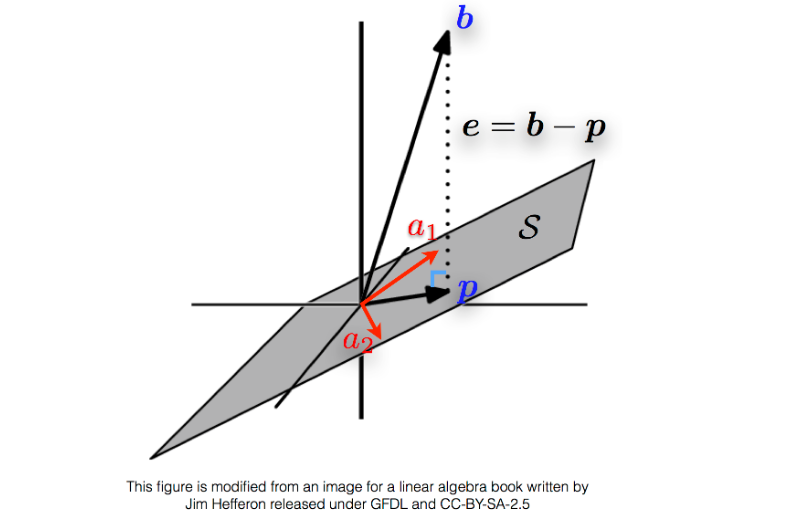

Pertimbangkan suatu subruang berdimensi dua $\mathcal{S}$ dari $\mathbb{R}^3$ yang dibentang oleh dua vektor 3D yang saling bebas linear, yaitu $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$:

$$
\mathcal{S} = \mathrm{span}\langle \boldsymbol{a}_1, \boldsymbol{a}_2 \rangle
$$

Misalkan $\boldsymbol{b}$ adalah sebuah vektor yang tidak berada di dalam $\mathcal{S}$. Permasalahannya adalah mencari titik $\boldsymbol{p} \in \mathcal{S}$ yang meminimalkan norma Euclidean dari kesalahan $\boldsymbol{e} = \boldsymbol{b} - \boldsymbol{p}$, dengan:

$$
\|\boldsymbol{e}\|_2 = \sqrt{\boldsymbol{e}^T \boldsymbol{e}}
$$

Secara geometris, kesalahan minimum diperoleh ketika $\boldsymbol{e}$ ortogonal terhadap subruang $\mathcal{S}$. Misalkan titik pada subruang dinyatakan sebagai:

$$
\boldsymbol{p} = x_1 \boldsymbol{a}_1 + x_2 \boldsymbol{a}_2
$$

Definisikan matriks:

$$
A =
\begin{bmatrix}
\boldsymbol{a}_1 & \boldsymbol{a}_2
\end{bmatrix}
$$

maka $\boldsymbol{p}$ dapat ditulis sebagai:

$$
\boldsymbol{p} = A \boldsymbol{x}, \quad
\boldsymbol{x} =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

Agar $\boldsymbol{e}$ ortogonal terhadap $\mathcal{S}$, cukup jika $\boldsymbol{e}$ ortogonal terhadap vektor basisnya, yaitu:

$$
\boldsymbol{a}_i^T \boldsymbol{e} = 0, \quad i = 1,2
$$

yang ekuivalen dengan:

$$
A^T \boldsymbol{e} = \boldsymbol{0}
$$

Substitusi $\boldsymbol{e} = \boldsymbol{b} - A\boldsymbol{x}$ memberikan:

$$
A^T(\boldsymbol{b} - A\boldsymbol{x}) = \boldsymbol{0}
$$

sehingga diperoleh *Normal Equations*:

$$
A^T A \boldsymbol{x} = A^T \boldsymbol{b}
$$

Setelah $\boldsymbol{x}$ diperoleh, maka proyeksi ortogonalnya adalah:

$$
\boldsymbol{p} = A \boldsymbol{x}
$$

### **Proyeksi Ortogonal Suatu Fungsi ke Ruang Fungsi Diskrit**

Jika Anda memahami masalah sebelumnya dari aljabar linear, Anda akan menyadari bahwa proyeksi ortogonal suatu fungsi ke ruang fungsi diskrit pada dasarnya adalah masalah yang sama, hanya menggunakan pendekatan yang sedikit berbeda.

Masalah ini dapat dinyatakan sebagai berikut: Diberikan suatu fungsi kontinu $f(x)$ dan ruang fungsi diskrit $\mathcal{V}_h$, tentukan fungsi $P_h f \in \mathcal{V}_h$ yang meminimalkan $|| f - P_h f||_{L^2}$.

Artinya, kita mencari fungsi dalam ruang $\mathcal{V}_h$ yang paling mendekati fungsi asli $f(x)$ jika diukur menggunakan norma $L^2$.

Sekali lagi, kita dapat membangun masalah ini secara geometris. Pertama, jika 
$P_h f \in \mathcal{V}_h$ maka fungsi tersebut dapat dituliskan dalam bentuk fungsi basis dari $\mathcal{V}_h$, yaitu

$$
P_h f(x) = \sum_{j=0}^{N} w_j \phi_j(x)
$$

Selanjutnya kita mendefinisikan residual (atau error) sebagai

$$
r(x) = f(x) - P_h f(x)
$$

Kemudian kita mensyaratkan bahwa residual tersebut harus $\textit{ortogonal}$ terhadap setiap fungsi 
$v_h \in \mathcal{V}_h$, dengan ortogonalitas fungsi didefinisikan terhadap norma $L^2$ dengan cara yang biasa. 
Artinya, dua fungsi $f$ dan $g$ dikatakan ortogonal jika

$$
\int_{\Omega} f g \, dx = 0
$$

Oleh karena itu, agar $r$ ortogonal terhadap setiap fungsi $v_h \in \mathcal{V}_h$, cukup jika $r$ ortogonal terhadap setiap fungsi basis dari $\mathcal{V}_h$. 
Untuk ruang fungsi berdimensi hingga, masalah ini menjadi mencari $P_h f \in \mathcal{V}_h$ sehingga

$$
\int_{\Omega} \phi_i(x) r(x)\, dx = 0
$$
untuk semua $i = 0, \ldots, N$.

Dengan menggunakan definisi $r(x)$ dan $P_h f(x)$ sebelumnya, masalah tersebut menjadi mencari vektor bobot 
$\boldsymbol{w} = [w_0, w_1, \ldots, w_N]^T$ sehingga

$$
\int_{\Omega} \phi_i(x) \sum_{j=0}^{N} w_j \phi_j(x)\, dx
=
\int_{\Omega} \phi_i(x) f(x)\, dx
$$

untuk semua $i = 0, \ldots, N$.

Ruas kanan (RHS) dari persamaan ini merupakan sekumpulan $N$ bilangan yang masing-masing menggambarkan 
hasil $\textit{inner product}$ $L^2$ antara $f$ dengan setiap fungsi basis. Dengan mendefinisikan

$$
\tilde{f}_i = \int_{\Omega} \phi_i(x) f(x)\, dx
\quad i = 0, \ldots, N
$$

maka ruas kanan dapat disusun menjadi sebuah vektor 
$\tilde{\boldsymbol{f}} \in \mathbb{R}^{N+1}$.

Ruas kiri (LHS) sedikit lebih kompleks, tetapi kita dapat menukar urutan penjumlahan dan integrasi sehingga diperoleh

$$
\int_{\Omega} \phi_i(x) \sum_{j=0}^{N} w_j \phi_j(x)\, dx
=
\sum_{j=0}^{N} w_j \int_{\Omega} \phi_i(x) \phi_j(x)\, dx
$$

Integral tentu terakhir ini menghasilkan sekumpulan bilangan dengan dua indeks

$$
M_{ij} = \int_{\Omega} \phi_i(x) \phi_j(x)\, dx
$$

yang mendefinisikan elemen-elemen dari $\textit{Mass Matrix}$ $M$.

Dengan demikian, masalah proyeksi ini sebenarnya dapat direduksi menjadi bentuk aljabar linear

$$
\sum_{j=0}^{N} M_{ij} w_j = \tilde{f}_i
$$

atau dalam notasi matriks-vektor

$$
M \boldsymbol{w} = \tilde{\boldsymbol{f}}
$$

Setelah $\boldsymbol{w}$ diperoleh dari sistem persamaan tersebut, maka fungsi proyeksi 
$P_h f(x)$ dapat ditentukan dari bobot dan fungsi basisnya.

Visualisasi berikut menunjukkan seluruh komponen yang diperlukan untuk menyusun matriks massa $M$ dan vektor beban $\tilde{\boldsymbol{f}}$.

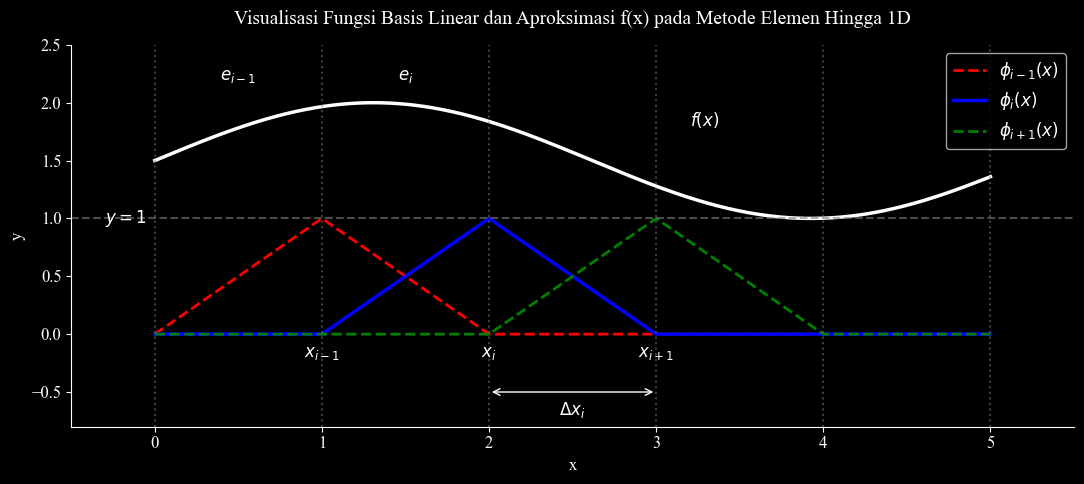

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

x_nodes = np.array([0, 1, 2, 3, 4, 5])

i = 2  # pusat (xi)

x = np.linspace(0, 5, 500)

f = 1.5 + 0.5*np.sin(1.2*x)

def phi(j, x):
    return np.where(
        (x >= x_nodes[j-1]) & (x <= x_nodes[j]),
        (x - x_nodes[j-1]) / (x_nodes[j] - x_nodes[j-1]),
        np.where(
            (x > x_nodes[j]) & (x <= x_nodes[j+1]),
            (x_nodes[j+1] - x) / (x_nodes[j+1] - x_nodes[j]),
            0
        )
    )

phi_im1 = phi(i-1, x)
phi_i   = phi(i, x)
phi_ip1 = phi(i+1, x)

fig, ax = plt.subplots(figsize=(11,5))

# kurva f(x)
ax.plot(x, f, color='white', linewidth=2.5)

# shape function
ax.plot(x, phi_im1, 'r--', linewidth=2, label=r'$\phi_{i-1}(x)$')
ax.plot(x, phi_i,   'b-',  linewidth=2.5, label=r'$\phi_i(x)$')
ax.plot(x, phi_ip1, 'g--', linewidth=2, label=r'$\phi_{i+1}(x)$')

for xn in x_nodes:
    ax.axvline(x=xn, color='gray', linestyle=':', alpha=0.5)

ax.axhline(y=1, color='gray', linestyle='--', alpha=0.6)
ax.text(-0.3, 1, r'$y=1$', va='center')

ax.text(x_nodes[i-1], -0.2, r'$x_{i-1}$', ha='center')
ax.text(x_nodes[i],   -0.2, r'$x_i$', ha='center')
ax.text(x_nodes[i+1], -0.2, r'$x_{i+1}$', ha='center')

ax.text((x_nodes[i-2]+x_nodes[i-1])/2, 2.2, r'$e_{i-1}$', ha='center')
ax.text((x_nodes[i-1]+x_nodes[i])/2,   2.2, r'$e_i$', ha='center')

ax.annotate("",
            xy=(x_nodes[i], -0.5),
            xytext=(x_nodes[i+1], -0.5),
            arrowprops=dict(arrowstyle='<->', color='white'))

ax.text((x_nodes[i]+x_nodes[i+1])/2, -0.7,
        r'$\Delta x_i$', ha='center')

ax.text(3.2, 1.8, r'$f(x)$')

ax.set_title("Visualisasi Fungsi Basis Linear dan Aproksimasi f(x) pada Metode Elemen Hingga 1D",
             fontsize=14,
             pad=15)

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.8, 2.5)

ax.set_xlabel("x")
ax.set_ylabel("y")

# styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### **Struktur Matriks Massa**

Struktur matriks massa dapat dipahami dengan meninjau fungsi basis pada interval satu dimensi yang terdiri dari $N$ elemen. Matriks massa $M$ berukuran $(N+1)\times(N+1)$ dengan elemen:

$$
M_{ij} = \int_{\Omega} \phi_i(x)\,\phi_j(x)\, dx
$$

Jika fungsi basis bersifat ortonormal (misalnya sinus, cosinus, atau polinomial Chebyshev), maka matriks massa menjadi matriks identitas. Namun, pada metode elemen hingga dengan fungsi basis berbentuk *hat function*, matriks massa bersifat jarang (*sparse*), karena hanya fungsi basis yang memiliki daerah dukungan yang saling tumpang tindih yang menghasilkan elemen tak nol.

Untuk kasus satu dimensi dengan fungsi basis linear ($P_1$), matriks massa berbentuk tridiagonal. Hal ini karena hanya interaksi antara $\phi_i$ dengan $\phi_{i-1}$ dan $\phi_{i+1}$ yang tidak nol.

Elemen-elemen pada baris ke-$i$ adalah:

$$
M_{i,i-1} = \int_{x_{i-1}}^{x_i} \phi_i \phi_{i-1} \, dx
$$

$$
M_{i,i} = \int_{x_{i-1}}^{x_{i+1}} \phi_i \phi_i \, dx
$$

$$
M_{i,i+1} = \int_{x_i}^{x_{i+1}} \phi_i \phi_{i+1} \, dx
$$

Elemen $M_{i,i-1}$ berasal dari elemen $e_{i-1}$, $M_{i,i+1}$ berasal dari elemen $e_i$, sedangkan elemen diagonal $M_{i,i}$ merupakan kontribusi dari keduanya:

$$
M_{i,i} =
\int_{x_{i-1}}^{x_i} \phi_i^2 \, dx +
\int_{x_i}^{x_{i+1}} \phi_i^2 \, dx
$$

Untuk fungsi basis $P_1$, nilai elemen dapat dihitung secara analitik. Sebagai contoh:

$$
M_{i,i-1} =
\int_{x_{i-1}}^{x_i}
\frac{x_i - x}{\Delta x_{i-1}}
\frac{x - x_{i-1}}{\Delta x_{i-1}} \, dx
$$

Dengan transformasi afin:

$$
x = x_{i-1} + s\,\Delta x_{i-1}, \quad s \in [0,1], \quad dx = \Delta x_{i-1}\, ds
$$

diperoleh:

$$
M_{i,i-1} =
\Delta x_{i-1} \int_0^1 (1 - s)s \, ds
=
\frac{\Delta x_{i-1}}{6}
$$

Dengan cara yang sama:

$$
M_{i,i} =
\frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3}
$$

$$
M_{i,i+1} =
\frac{\Delta x_i}{6}
$$

Sehingga satu baris matriks massa dapat dituliskan sebagai:

$$
M_i =
\begin{bmatrix}
\frac{\Delta x_{i-1}}{6} &
\frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3} &
\frac{\Delta x_i}{6}
\end{bmatrix}
$$

Bentuk matriks massa global adalah:

$$
M =
\begin{bmatrix}
\frac{\Delta x_0}{3} & \frac{\Delta x_0}{6} & & & \\
\frac{\Delta x_0}{6} &
\frac{\Delta x_0}{3} + \frac{\Delta x_1}{3} &
\frac{\Delta x_1}{6} & & \\
&
\frac{\Delta x_1}{6} &
\frac{\Delta x_1}{3} + \frac{\Delta x_2}{3} &
\frac{\Delta x_2}{6} & \\
& & \ddots & \ddots & \ddots \\
& & &
\frac{\Delta x_N}{6} &
\frac{\Delta x_N}{3}
\end{bmatrix}
$$

### **Mekanika: Perakitan Elemen (Element-wise Assembly)**

Meskipun matriks massa global dapat disusun secara langsung, pendekatan yang lebih sistematis adalah dengan melakukan perulangan pada setiap elemen dan menghitung kontribusi lokalnya terhadap matriks massa global.

Matriks massa $M$ dapat dipandang sebagai penjumlahan dari matriks-matriks elemen:

$$
M = M^{e_0} + M^{e_1} + \cdots + M^{e_N}
$$

dengan matriks massa lokal pada elemen $e_i$ diberikan oleh:

$$
M^{e_i} =
\frac{\Delta x_i}{6}
\begin{bmatrix}
2 & 1 \\
1 & 2
\end{bmatrix}
$$

Matriks ini dapat dinyatakan menggunakan fungsi basis lokal $N_0$ dan $N_1$ pada koordinat lokal:

$$
M^{e_i} =
\Delta x_i
\begin{bmatrix}
\int_0^1 N_0^2 \, dt & \int_0^1 N_0 N_1 \, dt \\
\int_0^1 N_0 N_1 \, dt & \int_0^1 N_1^2 \, dt
\end{bmatrix}
$$

Setiap matriks lokal berkontribusi pada matriks global melalui hubungan:

$$
M^{e_i} =
\begin{bmatrix}
M_{i,i} & M_{i,i+1} \\
M_{i+1,i} & M_{i+1,i+1}
\end{bmatrix}
$$

Dengan demikian, proses perakitan (*assembly*) matriks massa global dilakukan dengan langkah-langkah berikut:

- Melakukan perulangan untuk setiap elemen $i = 0, \ldots, N$
- Menghitung matriks massa lokal $M^{e_i}$
- Menambahkan kontribusi $M^{e_i}$ ke posisi yang sesuai dalam matriks global

Proses yang serupa digunakan untuk menyusun vektor beban (*load vector*) $\tilde{\boldsymbol{f}}$:

- Melakukan perulangan untuk setiap elemen $i = 0, \ldots, N$
- Menghitung kontribusi elemen terhadap vektor beban

$$
\tilde{\boldsymbol{f}}^{e_i} =
\begin{bmatrix}
\int_{x_i}^{x_{i+1}} N_0(x) f(x) \, dx \\
\int_{x_i}^{x_{i+1}} N_1(x) f(x) \, dx
\end{bmatrix}
=
\begin{bmatrix}
\tilde{f}_i \\
\tilde{f}_{i+1}
\end{bmatrix}
$$

### **Konvergensi/Optimalitas**

Pembahasan mengenai konvergensi dan optimalitas berkaitan dengan bagaimana solusi pendekatan akan semakin mendekati solusi eksak ketika ukuran elemen ($\Delta x$) diperkecil. Hal ini menjadi dasar penting dalam menjamin keakuratan metode elemen hingga.

### **Penyelesaian Persamaan Poisson 1-D dengan FEM**

Permasalahan proyeksi yang telah dibahas sebelumnya sebenarnya sudah menyediakan dasar mekanisme untuk menggunakan metode elemen hingga (FEM) dalam menyelesaikan persamaan diferensial parsial (PDE).

Sebagai contoh, kita tinjau masalah nilai batas dua titik paling sederhana dalam satu dimensi:

$$
-\frac{d^2 u}{dx^2} = f(x), \quad \text{pada} \quad \Omega = [0,1]
$$

dengan kondisi batas Dirichlet:

$$
u(0) = 0, \quad u(1) = 0
$$

Untuk menyederhanakan analisis, ambil $f(x) = 1$. Dengan demikian, diperoleh suatu masalah *Manufactured Solution* (MMS), yaitu kasus uji dengan solusi eksak yang sudah diketahui, yaitu:

$$
u(x) = \frac{1}{2} x(1 - x)
$$

Contoh ini digunakan sebagai model sederhana untuk memahami langkah-langkah penerapan metode elemen hingga. Pada bagian berikutnya akan dibahas tahapan penyusunan formulasi FEM dengan pendekatan Galerkin.

## **Memilih Ruang Fungsi (Mesh + Elemen)**

Langkah pertama adalah memilih ruang fungsi $\mathcal{V}_h$ untuk mendekati solusi diskrit. Interval satuan $\Omega = [0,1]$ dibagi menjadi $N$ elemen dengan ukuran $h_j$ (tidak harus seragam).

Solusi kemudian didekati menggunakan fungsi linear sepenggal ($P_1$), yaitu:

$$
u_h(x) = \sum_{j=0}^{N} w_j \, \phi_j(x)
$$

di mana $\phi_j(x)$ adalah fungsi basis berbentuk *hat function*, dan $w_j$ merupakan nilai solusi pada titik simpul (node).

Dalam bentuk kuat (*strong form*), persamaan diferensial memerlukan fungsi yang memiliki turunan kedua yang terdefinisi dengan baik. Namun, fungsi $P_1$ hanya memiliki turunan pertama yang kontinu, sedangkan turunan keduanya tidak kontinu di batas elemen.

Meskipun demikian, pendekatan ini tetap dapat digunakan karena formulasi metode elemen hingga tidak bekerja langsung pada bentuk kuat, melainkan pada bentuk lain yang lebih lemah (weak form), sehingga syarat kekontinuan yang dibutuhkan menjadi lebih longgar.

### **Membentuk Weak Form**

Seperti telah dijelaskan, fungsi diskrit $u_h(x)$ tidak dapat menjadi solusi langsung dari persamaan dalam bentuk kuat. Namun, untuk setiap fungsi, kita tetap dapat menghitung *residual* dengan mensubstitusikannya ke dalam persamaan tersebut:

$$
r(x) = -\frac{d^2 u_h}{dx^2} - f(x)
$$

Jika $u_h$ adalah solusi eksak, maka $r(x) = 0$. Karena ruang fungsi $\mathcal{V}_h$ tidak dapat memuat solusi kuat secara langsung, maka permasalahan diubah menjadi mencari fungsi $u_h \in \mathcal{V}_h$ yang meminimalkan norma residual.

Seperti pada masalah proyeksi, hal ini ekuivalen dengan mencari $u_h \in \mathcal{V}_h$ sehingga:

$$
\int_{\Omega} v \, r \, dx = 0
\quad \text{untuk semua } v \in \mathcal{V}_h
$$

Artinya, residual harus ortogonal terhadap seluruh fungsi dalam ruang $\mathcal{V}_h$.

Dengan mensubstitusikan bentuk residual, diperoleh:

$$
\int_{\Omega} v \left( -\frac{d^2 u_h}{dx^2} - f \right) dx = 0
$$

atau dapat dituliskan sebagai:

$$
\int_{\Omega} v \, \frac{d^2 u_h}{dx^2} \, dx
=
\int_{\Omega} v \, f \, dx
$$

untuk semua $v \in \mathcal{V}_h$.

#### **Beberapa Istilah Penting**

Persamaan dalam Bentuk Lemah (*weak form*) juga dikenal sebagai *variational form* dari suatu masalah. Dalam metode elemen hingga (FEM), terdapat beberapa istilah yang sering digunakan:

- $u_h$ disebut sebagai *trial function*, yaitu fungsi pendekatan yang digunakan sebagai solusi.

- $v$ disebut sebagai *test function*, yaitu fungsi dalam ruang $\mathcal{V}_h$ yang digunakan untuk menguji kondisi ortogonalitas residual.

- Sisi kiri dari bentuk lemah:

$$
a(u_h, v) = -\int_{\Omega} v \, \frac{d^2 u_h}{dx^2} \, dx
$$

disebut sebagai bentuk bilinear (*bilinear form*), karena melibatkan dua fungsi ($u_h$ dan $v$) dan bersifat linear terhadap masing-masing argumennya.

- Sisi kanan:

$$
L(v) = \int_{\Omega} v \, f \, dx
$$

disebut sebagai bentuk linear (*linear form*), karena menghasilkan satu nilai skalar untuk setiap fungsi $v$.

- Secara ringkas, persoalan variasional dapat dituliskan sebagai:

$$
a(u_h, v) = L(v)
$$

#### **Beberapa Terminologi**

Persamaan *weak form* juga dikenal sebagai *variational form* dari suatu masalah. Dalam metode *Finite Element Method* (FEM), beberapa istilah penting yang sering digunakan adalah:

- $u_h$ disebut sebagai *trial function*, yaitu fungsi pendekatan untuk solusi.
- $v$ disebut sebagai *test function*, yaitu fungsi dalam ruang $\mathcal{V}_h$ yang digunakan untuk menguji ortogonalitas residual.

Bagian kiri dari *weak form*:

$$
a(u_h, v) = -\int_{\Omega} v \, \frac{d^2 u_h}{dx^2} \, dx
$$

disebut sebagai **bilinear form** $a(u_h, v)$, karena melibatkan dua fungsi dan bersifat linear terhadap masing-masing.

Bagian kanan:

$$
L(v) = \int_{\Omega} v \, f \, dx
$$

disebut sebagai **linear form** $L(v)$, karena menghasilkan satu nilai skalar untuk setiap fungsi $v$.

Secara ringkas, bentuk variasional dapat dituliskan sebagai:

$$
a(u_h, v) = L(v)
$$

#### **Integrasi Parsial (Integration by Parts)**

Bentuk bilinear di atas masih kurang praktis, terutama jika $u_h$ berada pada ruang $P_1$. Oleh karena itu, digunakan *integration by parts* untuk memindahkan turunan dari *trial function* ke *test function*.

Diketahui:

$$
\frac{d^2 u_h}{dx^2} = \frac{d}{dx}\left(\frac{du_h}{dx}\right)
$$

dan aturan turunan hasil kali:

$$
\frac{d}{dx} \left( v \frac{du_h}{dx} \right)
= v \frac{d^2 u_h}{dx^2} + \frac{dv}{dx} \frac{du_h}{dx}
$$

Sehingga diperoleh:

$$
\begin{aligned}
a(u_h, v)
&= -\int_{\Omega} v \frac{d^2 u_h}{dx^2} \, dx \\
&= \int_{\Omega} \frac{dv}{dx} \frac{du_h}{dx} \, dx
- \int_{\Omega} \frac{d}{dx} \left( v \frac{du_h}{dx} \right) dx \\
&= \int_{\Omega} \frac{dv}{dx} \frac{du_h}{dx} \, dx
- \left. v \frac{du_h}{dx} \right|_{\partial \Omega}
\end{aligned}
$$

Suku terakhir merupakan kontribusi batas yang bergantung pada nilai $v$ dan turunan pertama $u_h$ di batas domain. Suku ini berkaitan dengan kondisi batas tipe Neumann (*flux boundary condition*).

Jika suku batas diabaikan, maka diperoleh bentuk bilinear yang lebih sederhana:

$$
a(u_h, v) = \int_{\Omega} \frac{dv}{dx} \frac{du_h}{dx} \, dx
$$

Bentuk ini hanya melibatkan turunan pertama, sehingga lebih sesuai untuk fungsi dalam ruang $P_1$, di mana gradien bersifat *piecewise constant*.

#### **Bentuk Lemah untuk Ruang Fungsi Berdimensi Hingga**

Semua konsep sebelumnya berlaku baik untuk ruang fungsi berdimensi tak hingga maupun berdimensi hingga. Namun, pada ruang fungsi berdimensi hingga dengan jumlah fungsi basis tetap, bentuk linear dan bilinear dapat dinyatakan sebagai operasi aljabar linear. Struktur ini serupa dengan yang muncul pada masalah proyeksi dan juga berlaku untuk persamaan Poisson.

Solusi pendekatan dinyatakan sebagai kombinasi fungsi basis:

$$
u_h(x) = \sum_{j=0}^{N} w_j \, \phi_j(x)
$$

Selanjutnya, setiap fungsi basis dipilih sebagai *test function*. Dengan demikian, masalah variasional menjadi:

- Cari $\boldsymbol{w} \in \mathbb{R}^{N+1}$ sehingga

$$
\int_{\Omega} \frac{d\phi_i}{dx}
\sum_{j=0}^{N} w_j \frac{d\phi_j}{dx} \, dx
=
\int_{\Omega} \phi_i \, f \, dx
$$

Dengan menukar urutan penjumlahan dan integrasi, diperoleh:

$$
\sum_{j=0}^{N} w_j
\int_{\Omega}
\frac{d\phi_i}{dx}
\frac{d\phi_j}{dx}
\, dx
=
\int_{\Omega} \phi_i \, f \, dx
$$

yang dapat dituliskan sebagai:

$$
\sum_{j=0}^{N} A_{ij} w_j = \tilde{f}_i
$$

dengan:

$$
A_{ij} =
\int_{\Omega}
\frac{d\phi_i}{dx}
\frac{d\phi_j}{dx}
\, dx,
\quad
\tilde{f}_i =
\int_{\Omega}
\phi_i \, f \, dx
$$

Secara ringkas, sistem ini dapat ditulis dalam bentuk matriks:

$$
A \boldsymbol{w} = \tilde{\boldsymbol{f}}
$$

di mana $A$ disebut sebagai **stiffness matrix** dan $\tilde{\boldsymbol{f}}$ disebut sebagai **load vector**. Dengan demikian, bentuk lemah dari persamaan diferensial parsial berubah menjadi sistem aljabar linear.

Sebagai perbandingan, pada masalah proyeksi diperoleh sistem:

$$
M \boldsymbol{w} = \tilde{\boldsymbol{f}}
$$

di mana $M$ adalah mass matrix, sedangkan $\tilde{\boldsymbol{f}}$ tetap merupakan *load vector*.

#### **Perakitan**

Perakitan (*assembly*) matriks kekakuan global dan vektor beban global dilakukan dengan cara yang sama seperti pada masalah proyeksi. Perbedaannya terletak pada matriks kekakuan yang kini melibatkan turunan fungsi basis. Untuk elemen $P_1$, perhitungannya masih sederhana.

Pertama, disusun **element stiffness matrix**:

$$
A^{e_i} =
\begin{bmatrix}
\int_{x_i}^{x_{i+1}} \left(\frac{dN_0}{dx}\right)^2 dx &
\int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx \\
\int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx &
\int_{x_i}^{x_{i+1}} \left(\frac{dN_1}{dx}\right)^2 dx
\end{bmatrix}
$$

dengan fungsi basis lokal:

$$
N_0(x) = \frac{x_{i+1} - x}{\Delta x_i}, \quad
N_1(x) = \frac{x - x_i}{\Delta x_i}
$$

Menggunakan transformasi afin $x = x_i + t\,\Delta x_i$, fungsi basis dalam koordinat lokal menjadi:

$$
N_0(t) = 1 - t, \quad N_1(t) = t
$$

Turunan terhadap $x$ diberikan oleh:

$$
\frac{dN_i}{dx} = \frac{1}{\Delta x_i} \frac{dN_i}{dt}
$$

Sehingga elemen matriks dapat dihitung, misalnya:

$$
A^{e_i}_{00} = \frac{1}{\Delta x_i} \int_0^1 dt = \frac{1}{\Delta x_i}
$$

Dengan cara yang sama, diperoleh matriks kekakuan elemen:

$$
A^{e_i} =
\frac{1}{\Delta x_i}
\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}
$$

Matriks kekakuan global kemudian dirakit dengan pola (*stencil*) untuk titik interior:

$$
A_i =
\begin{bmatrix}
-\frac{1}{\Delta x_{i-1}} &
\frac{1}{\Delta x_{i-1}} + \frac{1}{\Delta x_i} &
-\frac{1}{\Delta x_i}
\end{bmatrix}
$$

Untuk mesh seragam dengan $\Delta x_i = h$, bentuknya menjadi:

$$
A_i =
\frac{1}{h}
\begin{bmatrix}
-1 & 2 & -1
\end{bmatrix}
$$

yang identik dengan *finite difference stencil* orde dua untuk turunan kedua.

Matriks globalnya adalah:

$$
A =
\frac{1}{h}
\begin{bmatrix}
1  & -1 & & & \\
-1 & 2 & -1 & & \\
& -1 & 2 & -1 & \\
& & \ddots & \ddots & \ddots \\
& & & -1 & 2
\end{bmatrix}
$$

Dengan demikian, untuk persamaan Poisson 1-D dengan gaya konstan dan mesh seragam, metode Galerkin FEM dengan elemen $P_1$ menghasilkan diskretisasi yang sama dengan metode *finite difference* orde dua.

#### **Kondisi Batas**

Untuk melengkapi bentuk diskret dari persamaan diferensial eliptik ini, diperlukan penerapan *boundary conditions*.

Pada kondisi batas Neumann (flux), kondisi ini dapat langsung dimasukkan ke dalam *weak form*. Hal ini muncul dari proses *integration by parts* yang menghasilkan suku batas:

$$
\left. v \frac{du_h}{dx} \right|_{\partial \Omega}
$$

Sebelumnya, suku ini diabaikan karena sesuai dengan kondisi *no-flux*:

$$
\frac{du_h}{dx} = 0
$$

Namun, untuk kondisi Neumann yang lebih umum, nilai gradien di batas diketahui, misalnya:

$$
\frac{du_h}{dx} = \alpha
$$

Dalam hal ini, nilai $\alpha$ disubstitusikan langsung ke dalam suku batas tersebut. Karena hanya bergantung pada fungsi uji $v$, kontribusinya dapat dihitung dan ditambahkan ke dalam *load vector*.

Untuk kondisi batas Dirichlet, penerapannya sedikit berbeda. Jika nilai fungsi pada batas sudah diketahui, maka derajat kebebasan pada titik tersebut tidak termasuk dalam variabel yang dicari.

Salah satu pendekatan adalah:
- Menyelesaikan sistem hanya untuk titik interior
- Nilai pada batas dimasukkan kembali saat merekonstruksi solusi

Pendekatan lain adalah dengan tetap merakit sistem global, lalu memodifikasi matriks setelah proses *assembly*:
- Elemen diagonal pada baris terkait diganti menjadi 1
- Elemen lainnya pada baris tersebut dibuat 0
- Nilai batas dimasukkan ke dalam *load vector*

Namun, pendekatan ini dapat mengganggu sifat simetri matriks kekakuan. Oleh karena itu, pendekatan yang lebih baik adalah menghilangkan baris dan kolom yang bersesuaian dengan titik batas, kemudian menyesuaikan *load vector* sesuai kebutuhan.

### **Perangkat Lunak Tingkat Lanjut untuk Pemodelan Elemen Hingga**

Walaupun tidak terlalu sulit membuat skrip Python sederhana untuk menyelesaikan persamaan Poisson 1-D dengan elemen linear, mengembangkan program yang benar-benar modular dan dapat diperluas ke dimensi lebih tinggi, jenis elemen yang berbeda, atau metode penyelesaian lain merupakan pekerjaan yang cukup kompleks.

Untungnya, telah tersedia berbagai perangkat lunak dan pustaka (*library*) FEM, baik yang bersifat komersial maupun *open-source*. Salah satu yang cukup menarik secara matematis maupun komputasional adalah **FEniCS**, yang dikembangkan oleh *FEniCS Project*.

FEniCS menyediakan seperangkat pustaka dan alat komputasi untuk merancang serta menyelesaikan masalah berbasis *Partial Differential Equations* (PDE) menggunakan metode *Finite Element Method* (FEM) secara efisien.

Beberapa fitur utama dari FEniCS antara lain:

- Menyediakan antarmuka dalam bahasa **C++** dan **Python**
- Memiliki bahasa tingkat tinggi bernama **UFL (Unified Form Language)** untuk menuliskan *weak form* yang bentuknya sangat mirip dengan persamaan integral matematis
- UFL mendukung:
  - berbagai jenis elemen kontinu dan diskontinu
  - operator vektor dan tensor seperti *div*, *grad*, dan *curl*
  - diferensiasi otomatis dari bentuk matematis (berguna untuk masalah nonlinier)
- FFC (FEniCS Form Compiler): menerjemahkan UFL menjadi kode C++ untuk proses *assembly*
- **DOLFIN**: pustaka utama yang menangani mesh, proses assembly, solver, serta input/output dan visualisasi
- Mendukung integrasi dengan pustaka solver numerik seperti **PETSc** dan **Trilinos**

Untuk memahami cara kerjanya, biasanya lebih mudah dengan melihat contoh kode Python. Contoh berikut diadaptasi dari demo resmi FEniCS untuk menyelesaikan persamaan Poisson, yang dimodifikasi untuk kasus 1-D yang telah dibahas sebelumnya.

In [ ]:
"""
This demo program solves Poisson's equation in 1-D

    - d^2 u / dx^2 = f(x)

on the unit interval with source:

    f(x) = 1

and homogeneous Dirichlet boundary conditions:

    u(0) = u(1) = 0
"""

# Modified from demo_poisson.py from the FEniCS demos


from dolfin import *                                          # Import library utama FEniCS

mesh = UnitIntervalMesh(32)                                   # Membuat mesh 1D dengan 32 elemen
V = FunctionSpace(mesh, "Lagrange", 1)                        # Ruang fungsi P1 (linear)

def boundary(x):                                              # Fungsi untuk mendeteksi boundary
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS       # x=0 atau x=1

u0 = Constant(0.0)                                            # Nilai Dirichlet = 0
bc = DirichletBC(V, u0, boundary)                             # Terapkan BC ke ruang fungsi

u = TrialFunction(V)                                          # Trial function (solusi)
v = TestFunction(V)                                           # Test function
f = Constant(1.0)                                             # Source term f(x)=1

a = v.dx(0) * u.dx(0) * dx                                   # Bilinear form (stiffness)
L = f * v * dx                                               # Linear form (load)

u = Function(V)                                              # Fungsi untuk menyimpan solusi
solve(a == L, u, bc)                                         # Menyelesaikan sistem FEM

file = File("poisson.pvd")                                   # File output (VTK format)
file << u                                                    # Simpan hasil solusi

plot(u, interactive=True)                                    # Plot hasil (mode interaktif)

ModuleNotFoundError: No module named 'dolfin'

Dan berikut adalah masalah yang sama, tetapi dengan kondisi batas Neumann pada sisi kanan, yaitu:

$$
\frac{du_h}{dx} = \alpha
$$

Kondisi ini hanya menambahkan satu suku tambahan pada bentuk linear (*linear form*). Suku tambahan ini berasal dari integral permukaan (*surface integrals*) pada bentuk bilinear.

In [ ]:
"""
Solve 1D Poisson equation:

    - d^2 u / dx^2 = f(x)

on [0,1] with:
    f(x) = 1

Boundary conditions:
    u(0) = 0          (Dirichlet)
    du/dx = alpha     (Neumann at x = 1)
"""

from dolfin import *                                      # Import FEniCS core

mesh = UnitIntervalMesh(32)                               # Mesh 1D
V = FunctionSpace(mesh, "Lagrange", 1)                    # Elemen linear (P1)

def left_boundary(x, on_boundary):                        # Boundary x = 0
    return on_boundary and near(x[0], 0.0)

def right_boundary(x, on_boundary):                       # Boundary x = 1
    return on_boundary and near(x[0], 1.0)

u0 = Constant(0.0)                                       # Dirichlet value
bc = DirichletBC(V, u0, left_boundary)                   # Terapkan di x=0

alpha = Constant(-0.25)                                  # Neumann value (flux)

# Tandai boundary untuk integrasi ds
boundary_markers = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundary_markers.set_all(0)
AutoSubDomain(right_boundary).mark(boundary_markers, 1)

ds = Measure("ds", domain=mesh, subdomain_data=boundary_markers)

u = TrialFunction(V)                                     # Trial function
v = TestFunction(V)                                      # Test function
f = Constant(1.0)                                        # Source term

a = dot(grad(u), grad(v)) * dx                           # Bilinear form
L = f * v * dx + alpha * v * ds(1)                       # Tambahan Neumann di x=1

u = Function(V)                                          # Solution container
solve(a == L, u, bc)                                     # Solve system
 
file = File("poisson_neumann.pvd")                       # Output file
file << u

plot(u)                                                  # Visualisasi

## **Finite Elements in Higher Dimensions**

Salah satu keunggulan FEniCS adalah kemampuannya untuk menuliskan dan menyelesaikan persamaan diferensial parsial (PDE) berdimensi lebih tinggi dengan usaha yang hampir sama seperti pada kasus 1-D. Sebagai contoh, kita pertimbangkan masalah berikut beserta formulasinya.

### **Strong Form**

Kita ingin menyelesaikan masalah Poisson umum pada domain persegi panjang:

$$
-\nabla \cdot \big( \alpha(x,y)\nabla u \big) = f(x,y),
\quad \text{pada} \quad \Omega = [0,2] \times [0,1]
$$

dengan $\alpha(x,y) > 0$ pada domain $\Omega$ (jika $\alpha = 1$, maka menjadi persamaan Poisson standar).

Sumber diberikan oleh:

$$
f(x,y) = 10 \exp\left( -\frac{(x - 1)^2 + (y - 1/2)^2}{0.02} \right)
$$

Kondisi batas Dirichlet pada arah $x$:

$$
u(0,y) = 0, \quad u(2,y) = 0
$$

Kondisi batas Neumann (flux) pada arah $y$:

$$
\alpha(x,y)\,\nabla u \cdot \hat{n} = \sin(5x),
\quad \text{pada} \quad y = 0,1
$$

### **Weak Form**

Untuk membentuk *weak form*, dipilih ruang fungsi $\mathcal{V}_h$, misalnya fungsi linear sepenggal pada elemen segitiga.

Masalah variasionalnya adalah:

Temukan $u \in \mathcal{V}_h$ sehingga

$$
-\int_{\Omega} v \, \nabla \cdot (\alpha \nabla u)\, dx
=
\int_{\Omega} v f \, dx
$$

untuk semua fungsi uji $v \in \mathcal{V}_h$.

Dengan melakukan integrasi parsial (*integration by parts*), diperoleh:

$$
\begin{aligned}
-\int_{\Omega} v \, \nabla \cdot (\alpha \nabla u)\, dx
&= \int_{\Omega} \nabla v \cdot (\alpha \nabla u)\, dx
- \int_{\partial \Omega} v \, (\alpha \nabla u \cdot \hat{n})\, ds
\end{aligned}
$$

Pada langkah ini digunakan teorema divergensi Gauss untuk memindahkan integral ke batas domain, sehingga kondisi batas Neumann dapat dimasukkan secara langsung.

Dengan demikian, *weak form* dapat dituliskan sebagai:

$$
a(u, v) = L(v)
$$

dengan:

$$
a(u, v) = \int_{\Omega} \nabla v \cdot \alpha \nabla u \, dx
$$

$$
L(v) = \int_{\Omega} v f \, dx + \int_{\partial \Omega} v g \, ds
$$

di mana:

$$
g(x,y) = \alpha \nabla u \cdot \hat{n} = \sin(5x)
$$

Menariknya, bentuk ini dapat langsung diterjemahkan ke dalam kode FEniCS dengan struktur yang sangat mirip dengan notasi matematisnya.